/tmp/ipython-input-1731517707.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


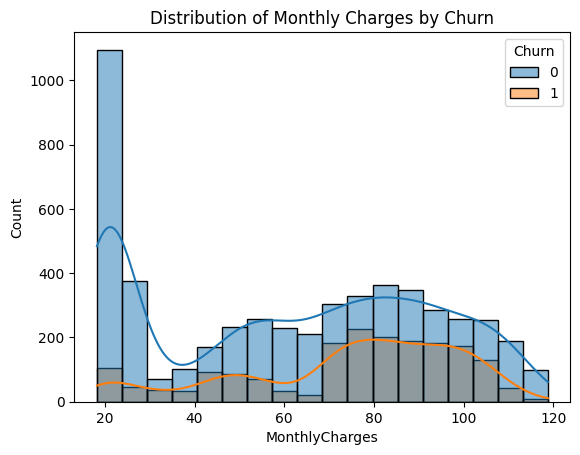

In [ ]:
# 1. Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 2. Load Data
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# 3. Data Cleaning
# TotalCharges is object type but should be numeric; coerce errors to NaN and fill
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

# Convert Target to Binary (0/1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Quick EDA
print(df['Churn'].value_counts(normalize=True)) # Check for class imbalance
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True)
plt.title("Distribution of Monthly Charges by Churn")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import joblib

# 1. Split Data
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define Preprocessing
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['gender', 'Partner', 'Dependents', 'PhoneService',
                        'MultipleLines', 'InternetService', 'OnlineSecurity',
                        'OnlineBackup', 'DeviceProtection', 'TechSupport',
                        'StreamingTV', 'StreamingMovies', 'Contract',
                        'PaperlessBilling', 'PaymentMethod']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])

# 3. Define Model Pipelines
pipeline_lr = Pipeline([('preprocessor', preprocessor),
                        ('classifier', LogisticRegression())])

pipeline_rf = Pipeline([('preprocessor', preprocessor),
                        ('classifier', RandomForestClassifier(random_state=42))])

# 4. Tuning (Example with Random Forest)
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None]
}

grid_search = GridSearchCV(pipeline_rf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

# 5. Evaluation
print("Best Params:", grid_search.best_params_)
y_pred = grid_search.predict(X_test)
print(classification_report(y_test, y_pred))

# 6. Save the Best Model
joblib.dump(grid_search.best_estimator_, 'churn_model.joblib')
print("Model saved as churn_model.joblib")

Best Params: {'classifier__max_depth': 10, 'classifier__n_estimators': 200}
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1036
           1       0.68      0.53      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

Model saved as churn_model.joblib
